<span style="color: blue;">**Fetal Health Classification**</span>

**Objective of the Study:**

The goal of this study is to develop predictive models for fetal health classification using features extracted from Cardiotocography (CTG) data, including fetal heart rate, uterine contractions, and various deceleration and variability indicators.

To ensure robust model evaluation and selection, I will use Stratified Cross-Validation to compare multiple machine learning algorithms (XGBoost, Random Forest, Decision Tree, and Logistic Regression). The study incorporates SMOTE to handle class imbalance, RFE for feature selection, and Bayesian optimization for hyperparameter tuning to identify the best performing model.

**Live Application:**

Explore the deployed interactive Streamlit app for real-time fetal health prediction: [https://your-streamlit-app-link-here](https://fetal-health-classifier-ck9d9slqswyhhtv6vejsn7.streamlit.app/)

In [ ]:
# Data Handling
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.feature_selection import RFE

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# Load Fetal Health Dataset
df = pd.read_csv("fetal_health.csv")

# Preview the first 5 rows
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120,0.000,0.0,0.000,0.000,0.0,0.0,73,0.5,43,2.4,64,62,126,2,0,120,137,121,73,1,2
1,132,0.006,0.0,0.006,0.003,0.0,0.0,17,2.1,0,10.4,130,68,198,6,1,141,136,140,12,0,1
2,133,0.003,0.0,0.008,0.003,0.0,0.0,16,2.1,0,13.4,130,68,198,5,1,141,135,138,13,0,1
3,134,0.003,0.0,0.008,0.003,0.0,0.0,16,2.4,0,23.0,117,53,170,11,0,137,134,137,13,1,1
4,132,0.007,0.0,0.008,0.000,0.0,0.0,16,2.4,0,19.9,117,53,170,9,0,137,136,138,11,1,1


In [ ]:
# Check the shape of the dataset
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 2126
Number of Columns: 22


In [ ]:
# Check missing values
df.isnull().sum().sum()

np.int64(0)

In [ ]:
# Count duplicate rows
df.duplicated().sum()

np.int64(13)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
# Dataset structure overview
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2113 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2113 non-null   int64  
 1   accelerations                                           2113 non-null   float64
 2   fetal_movement                                          2113 non-null   float64
 3   uterine_contractions                                    2113 non-null   float64
 4   light_decelerations                                     2113 non-null   float64
 5   severe_decelerations                                    2113 non-null   float64
 6   prolongued_decelerations                                2113 non-null   float64
 7   abnormal_short_term_variability                         2113 non-null   int64  
 8   mean_value_of_short_term_variability       

In [ ]:
# Set pandas to display all columns in the DataFrame
pd.set_option("display.max_columns", None)

In [ ]:
# Display summary statistics of numeric columns
df.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000
mean,133.304780,0.003188,0.009517,0.004387,0.001901,0.000003,0.000159,46.993848,1.335021,9.795078,8.166635,70.535258,93.564600,164.099858,4.077142,0.325603,137.454330,134.599621,138.089446,18.907241,0.318504,1.303833
std,9.837451,0.003871,0.046804,0.002941,0.002966,0.000057,0.000592,17.177782,0.884368,18.337073,5.632912,39.007706,29.562269,17.945175,2.951664,0.707771,16.402026,15.610422,14.478957,29.038766,0.611075,0.614279
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.000000,0.000000,3.000000,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.005000,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,68.000000,93.000000,162.000000,4.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.000000,50.700000,180.000000,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


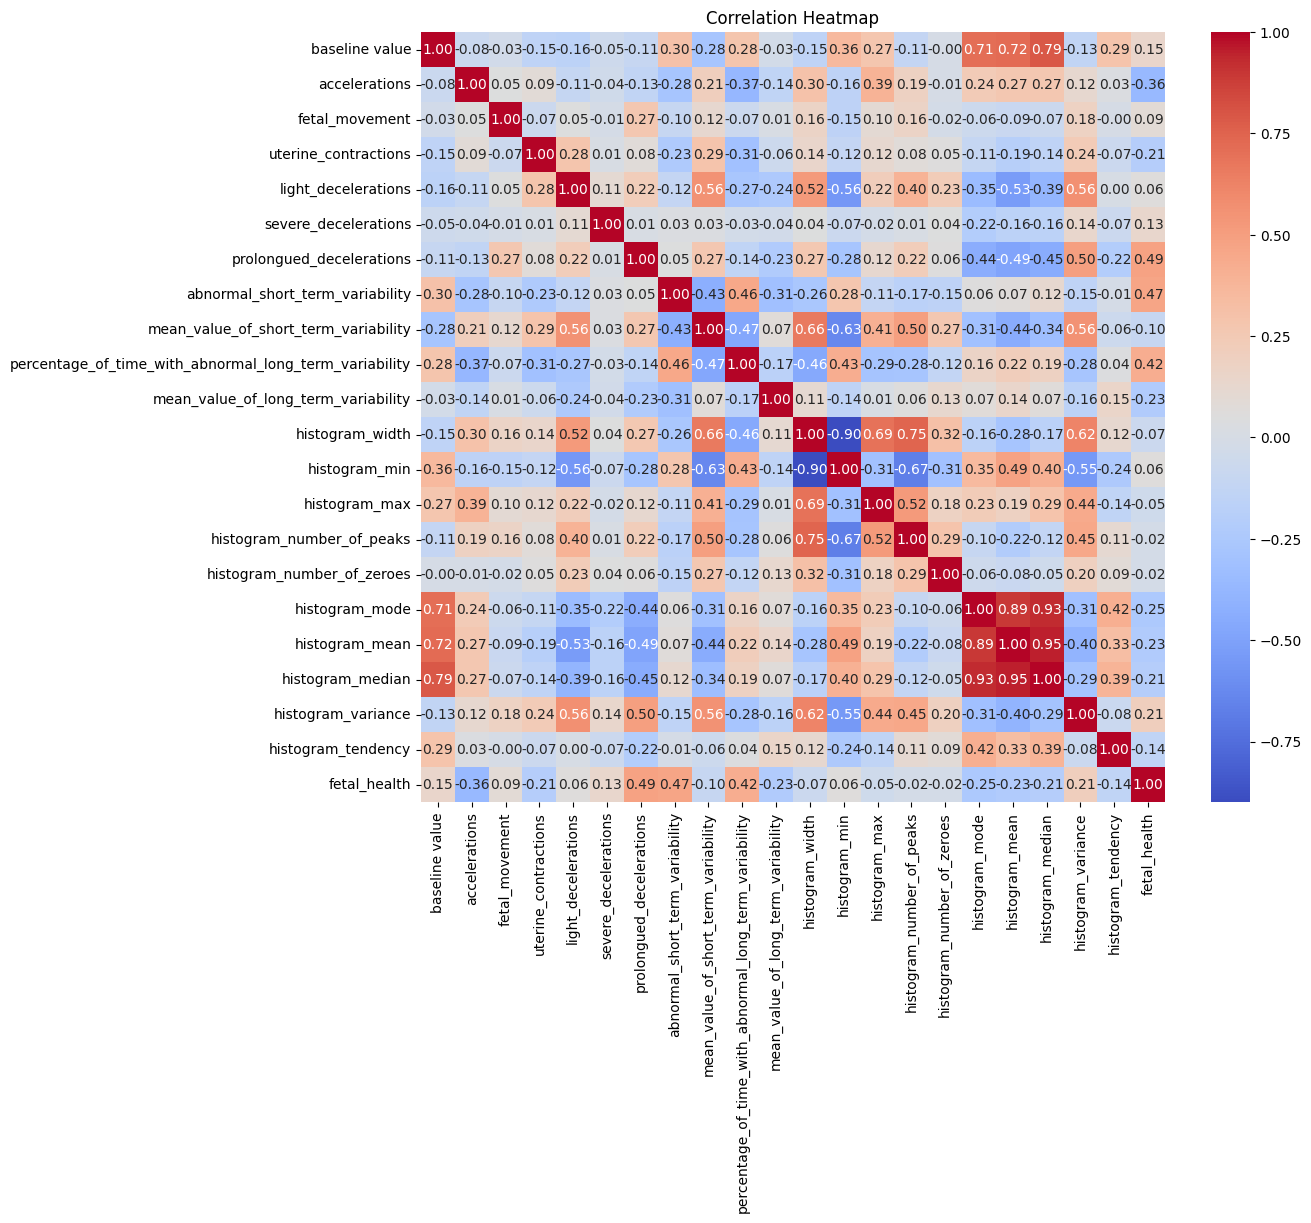

In [ ]:
# Compute correlation matrix
corr = df.corr()

# Set figure size
plt.figure(figsize=(12, 10))

# Plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

Correlated variables were retained because XGBoost, a tree-based ensemble model, is inherently robust to multicollinearity. Since the primary objective of this study is to maximize predictive accuracy for real-time fetal health assessment, preserving potentially informative CTG features was prioritized over dimensionality reduction. Removing correlated features may risk losing clinically relevant signals that contribute to accurate detection of fetal distress.

fetal_health
1    1646
2     292
3     175
Name: count, dtype: int64


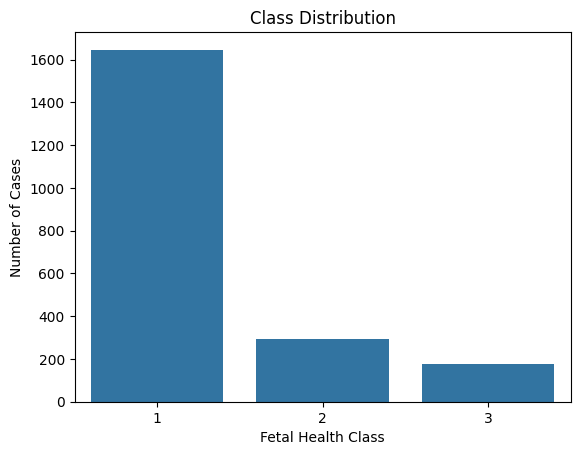

In [ ]:
# Check class distribution
print(df['fetal_health'].value_counts())

# Visualize class imbalance
sns.countplot(x='fetal_health', data=df)

plt.title("Class Distribution")
plt.xlabel("Fetal Health Class")
plt.ylabel("Number of Cases")

plt.show()

This plot shows the class distribution of the fetal_health target variable in the dataset. The dataset is highly imbalanced, with the majority of cases (1646) belonging to Class 1 (Normal), while Class 2 (Suspected Abnormality) and Class 3 (Abnormal) have only 292 and 175 cases, respectively.

In [ ]:
# Split the dataset into features (X) and target variable (y)
X = df.drop("fetal_health", axis=1)
y = df["fetal_health"]

In [ ]:
# Original labels
y_original = y.copy()

# Shift labels to start at 0 (since the datadet contains 1, 2, 3 it becomes 0, 1, 2)
y = y - 1

The target variable fetal_health originally contains labels 1, 2, and 3. To ensure compatibility with machine learning algorithms, the labels were shifted to start from 0 (i.e., 0, 1, 2).

In [ ]:
# Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Model Comparison Using 5-Fold Stratified Cross-Validation
models = {
    'XGBoost': XGBClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced',
                                             multi_class='multinomial', solver='lbfgs')
}

# Cross-validation setup
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run CV and collect results
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    cv_results[name] = scores.mean()
    print(f"{name} Average CV Accuracy: {scores.mean():.4f}")

# Find best model
best_model_name = max(cv_results, key=cv_results.get)
print("\nBest Model Based on CV Accuracy:", best_model_name)

XGBoost Average CV Accuracy: 0.9479
RandomForest Average CV Accuracy: 0.9352
DecisionTree Average CV Accuracy: 0.9091
LogisticRegression Average CV Accuracy: 0.8060

Best Model Based on CV Accuracy: XGBoost


In [ ]:
# Install scikit-optimize
!pip install scikit-optimize

In [ ]:
# Install scikit-optimize for Bayesian Hyperparameter Tuning
from skopt import BayesSearchCV

In [ ]:
# Bayesian Hyperparameter Optimization of XGBoost with SMOTE (Stratified 5-Fold CV)
xgb = XGBClassifier(
    objective='multi:softmax',
    random_state=42,
    n_jobs=1,
    tree_method='hist'
)

# Create a pipeline: SMOTE -> XGBoost
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb)
])

# Hyperparameter search space for XGBoost inside the pipeline
xgb_search_space = {
    'xgb__n_estimators': (100, 500),
    'xgb__max_depth': (3, 15),
    'xgb__learning_rate': (0.01, 0.3, 'log-uniform'),
    'xgb__subsample': (0.5, 1.0, 'uniform'),
}

# 5-fold Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Bayesian Optimization with Accuracy
opt_xgb = BayesSearchCV(
    estimator=pipeline,
    search_spaces=xgb_search_space,
    n_iter=20,
    scoring='accuracy',
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=1
)

# Fit the model
opt_xgb.fit(X_train, y_train)

# Output results
print("Best XGBoost Parameters:", opt_xgb.best_params_)
print("Best CV Accuracy:", opt_xgb.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [ ]:
# Evaluate Tuned XGBoost Model on Training and Test Sets
best_xgb_model = opt_xgb.best_estimator_

# Evaluate on training set
y_pred_train = best_xgb_model.predict(X_train)
acc_train = accuracy_score(y_train, y_pred_train)

# Evaluate on test set
y_pred_test = best_xgb_model.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)

print("XGBoost Classification Performance:")
print(f"Train Accuracy: {acc_train:.4f}")
print(f"Test Accuracy: {acc_test:.4f}")

XGBoost Classification Performance:
Train Accuracy: 0.9988
Test Accuracy: 0.9527


In [ ]:
# Extract only the tuned XGBoost model (without SMOTE wrapper)
tuned_xgb = opt_xgb.best_estimator_.named_steps['xgb']

# Apply RFE
rfe = RFE(
    estimator=tuned_xgb,
    n_features_to_select=10,
    step=1
)

rfe.fit(X_train, y_train)

RFE(estimator=XGBClassifier(base_score=None, booster=None, callbacks=None,
                            colsample_bylevel=None, colsample_bynode=None,
                            colsample_bytree=None, device=None,
                            early_stopping_rounds=None,
                            enable_categorical=False, eval_metric=None,
                            feature_types=None, feature_weights=None,
                            gamma=None, grow_policy=None, importance_type=None,
                            interaction_constraints=None,
                            learning_rate=0.15171809566296443, max_bin=None,
                            max_cat_threshold=None, max_cat_to_onehot=None,
                            max_delta_step=None, max_depth=8, max_leaves=None,
                            min_child_weight=None, missing=nan,
                            monotone_constraints=None, multi_strategy=None,
                            n_estimators=311, n_jobs=1, num_parallel_tree=None, ...),
    n_features_to_select=10)

In [ ]:
# Selected feature names
selected_features = X_train.columns[rfe.support_]

print("Top Features Selected by RFE:")
print(selected_features)

Top Features Selected by RFE:
Index(['baseline value', 'accelerations', 'prolongued_decelerations',
       'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'histogram_number_of_peaks', 'histogram_mode', 'histogram_mean',
       'histogram_median'],
      dtype='object')


In [ ]:
# Feature rankings
feature_ranking = pd.DataFrame({
    "Feature": X_train.columns,
    "Ranking": rfe.ranking_
}).sort_values(by="Ranking")

print(feature_ranking)

                                              Feature  Ranking
0                                      baseline value        1
1                                       accelerations        1
6                            prolongued_decelerations        1
7                     abnormal_short_term_variability        1
9   percentage_of_time_with_abnormal_long_term_var...        1
14                          histogram_number_of_peaks        1
8                mean_value_of_short_term_variability        1
16                                     histogram_mode        1
17                                     histogram_mean        1
18                                   histogram_median        1
2                                      fetal_movement        2
3                                uterine_contractions        3
19                                 histogram_variance        4
13                                      histogram_max        5
12                                      histogram_min  

Although XGBoost is inherently invariant to feature scaling due to its tree-based structure, scaling was applied within the pipeline together with SMOTE to maintain a consistent and structured preprocessing workflow. This ensures that all data transformations are handled systematically within a single, reproducible pipeline. The modeling process was conducted using the top 10 features selected through Recursive Feature Elimination (RFE) to improve model efficiency and focus on the most informative predictors.

In [ ]:
# Top 10 features based on importance
top_10_features = [
    "baseline value",
    "accelerations",
    "fetal_movement",
    "prolongued_decelerations",
    "abnormal_short_term_variability",
    "mean_value_of_short_term_variability",
    "percentage_of_time_with_abnormal_long_term_variability",
    "histogram_mode",
    "histogram_mean",
    "histogram_median"
]

# Subset the training and testing data
X_train_top = X_train[top_10_features]
X_test_top = X_test[top_10_features]

# Define XGB
xgb_model = XGBClassifier(
    n_estimators=165,
    max_depth=14,
    learning_rate=0.121,
    subsample=0.594,
    colsample_bytree=1.0,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1,
    objective='multi:softmax',
    eval_metric='mlogloss',
    random_state=42,
    tree_method='hist'
)

# Create pipeline using imblearn.pipeline.Pipeline
pipeline_1 = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('xgb', xgb_model)
])

# Fit the pipeline
pipeline_1.fit(X_train_top, y_train)

# Predictions
y_pred_train = pipeline_1.predict(X_train_top)
y_pred_test = pipeline_1.predict(X_test_top)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("\nTest Classification Report:")
print(classification_report(y_test, y_pred_test))

Train Accuracy: 0.9982248520710059
Test Accuracy: 0.9550827423167849

Test Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       330
           1       0.92      0.78      0.84        58
           2       0.94      0.97      0.96        35

    accuracy                           0.96       423
   macro avg       0.94      0.91      0.92       423
weighted avg       0.95      0.96      0.95       423



The model achieved an extremely high training accuracy of 99.82% and a strong test accuracy of 95.51%, indicating excellent overall performance.

On the test set, the model performed very well across the three classes, particularly for Class 0 and Class 2, with F1-scores of 0.97 and 0.96 respectively, demonstrating strong precision and recall. Performance for Class 1 was slightly weaker, with a recall of 0.78 and an F1-score of 0.84, meaning some instances of this class were missed compared to the others. The macro-average F1-score of 0.92 suggests balanced performance across all classes despite class imbalance, while the weighted average F1-score of 0.95 reflects strong overall predictive stability.

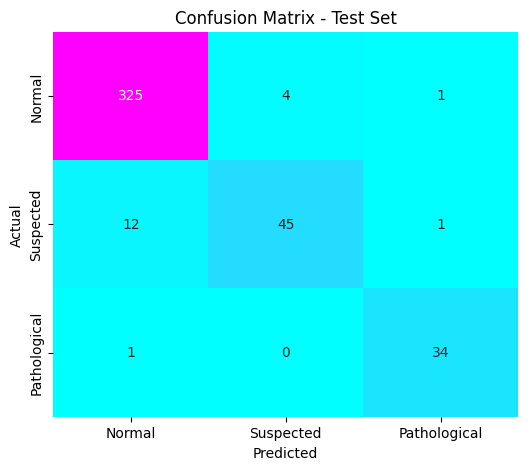

In [ ]:
# Visualizing Model Performance with Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)

class_names = ["Normal", "Suspected", "Pathological"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='cool', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.show()

The XGBoost model for fetal health classification demonstrates strong performance on the test dataset, aligning well with the study’s objective to evaluate fetal health status accurately using historical CTG data while minimizing false positives and false negatives in a clinical setting.

As seen in the confusion matrix, the model correctly classifies the majority of normal fetuses (325/330) and pathological cases (34/35), ensuring that critical conditions are rarely missed, which is essential for clinical safety. Suspected cases show some misclassification, with 12 out of 58 predicted as normal and 1 as pathological, reflecting moderate ambiguity in borderline cases. Overall, the model effectively distinguishes between normal, suspected, and pathological fetal conditions, providing a reliable decision-support tool that can help clinicians prioritize interventions and reduce the risk of misdiagnosis.

In [ ]:
import joblib
joblib.dump(pipeline_1, 'loan_payback_pipeline.pkl')

['loan_payback_pipeline.pkl']

In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


In [ ]:
import xgboost
print(xgboost.__version__)

3.2.0


**Conclusion:**

The development of the Fetal Health Classification System using XGBoost demonstrates the potential of machine learning to enhance prenatal care by providing accurate, real-time predictions of fetal well-being. By analyzing Cardiotocography (CTG) measurements including fetal heart rate, uterine contractions, and deceleration patterns the model successfully classifies fetuses as Normal, Suspected, or Pathological.

This system not only automates the interpretation of CTG data but also supports healthcare professionals in making timely, data-driven decisions, reducing the likelihood of delayed interventions or unnecessary procedures. The incorporation of techniques such as feature selection, handling class imbalance via SMOTE, and hyperparameter tuning with Bayesian Optimization ensures robust model performance while maintaining interpretability through feature importance insights.

Ultimately, this predictive model contributes to safer pregnancies, improved maternal and fetal outcomes, and more efficient clinical decision-making. With deployment through an interactive Streamlit application, the system bridges the gap between advanced machine learning and practical clinical application, enabling real-time fetal health assessment in a user-friendly environment.